<a href="https://colab.research.google.com/github/ixau0-0/final-project/blob/main/01_cleaning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

هنا حملنا البيانات وعرضنا اول خمسة

In [ ]:
data=pd.read_csv('insurance.csv') # حملنا قاعدة البيانات
print(data.head()) #عرضنا الخمس الصفوف الاولى

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


تعرفنا على عدد الصفوف والاعمدة وانواعها قبل ما ننظف البيانات

In [ ]:
print("shape before data cleaning",data.shape)

shape before data cleaning (1338, 7)


In [ ]:
print('info before data cleaning',data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
info before data cleaning None


هنا نظفنا البيانات تحت مسمى (clean_data)

In [ ]:
def clean_data(df):
    df['sex']=df['sex'].astype('category')
    df['smoker']=df['smoker'].astype('category')
    df['region']=df['region'].astype('category')
    #طبعاً تسأل ليه غيرنا انواعها عشان يساعدني في التحليل بعدين في الخطوات القادمة
    print('missing values\n',df.isnull().sum())#مافي قيم مفقودة
    print('duplicated\n',df.duplicated().sum())
    df.drop_duplicates(inplace=True)
    print('duplicated\n',df.duplicated().sum())#هاذي خطوه لضمان عدم وجود قيمة متكرره بعد الحذف

    numeric_cols = df.select_dtypes(include='number').columns#وضعنا متغير يحتوي على جميع الاعمدة الرقمية

    for col in numeric_cols:#هنا سوينا لوب عشان نعالج القيم المتطرفة في كل عمود رقمي
     cap = df[col].quantile(0.99)
     df[col + '_capped'] = df[col].apply(lambda x: min(x, cap))# هنا سوينا عمود جديد يحتوي على القيم الجديدة

   #ضفنا اربع عواميد فيها جميع البيانات بس بدون ذاك التاثير حق القيم المتطرفة عشان سوينا (capping)

    return df
df_clean = clean_data(data)


missing values
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
duplicated
 1
duplicated
 0


In [ ]:
print('info after data cleaning',df_clean.info())
print('shape after data cleaning',df_clean.shape)

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   age              1337 non-null   int64   
 1   sex              1337 non-null   category
 2   bmi              1337 non-null   float64 
 3   children         1337 non-null   int64   
 4   smoker           1337 non-null   category
 5   region           1337 non-null   category
 6   charges          1337 non-null   float64 
 7   age_capped       1337 non-null   int64   
 8   bmi_capped       1337 non-null   float64 
 9   children_capped  1337 non-null   int64   
 10  charges_capped   1337 non-null   float64 
dtypes: category(3), float64(4), int64(4)
memory usage: 98.4 KB
info after data cleaning None
shape after data cleaning (1337, 11)


هنا رسمنا التكاليف قبل وبعد ال (capping)

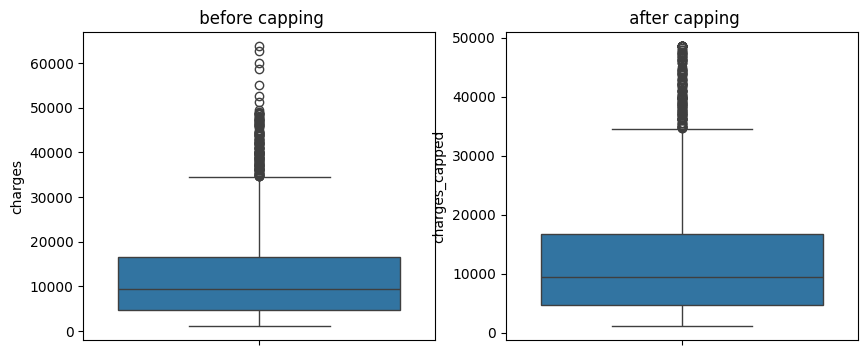

In [ ]:
plt.figure(figsize=(10,4))#مهمة الكود حجم الرسمة
plt.subplot(1,2,1)# حددنا المكان
sns.boxplot(y=df_clean['charges'])# حددنا الشي الي نبغاه ينرسم
plt.title(' before capping')
plt.subplot(1,2,2)
sns.boxplot(y=df_clean['charges_capped'])
plt.title(' after capping')
plt.show()


هنا عملية للتحقق وتاكيد

In [ ]:
if df_clean.isnull().sum().sum() == 0:
    print(" no missing values")
else:
    print(" there are missing values")

if (df_clean['charges'] > 0).all():
    print(" all charges are positive")
else:
    print(" not all charges are positive")

if df_clean.shape[1] == 11:
    print(" number of columns is correct")
else:
    print(" عدد الأعمدة تغير")

 no missing values
 all charges are positive
 number of columns is correct


لتحميل العمل

In [ ]:
df_clean.to_csv('cleaned_data.csv', index=False)
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>